In [18]:
%matplotlib inline
import pandas as pd
import numpy as np
import torch
from torch import nn, optim
from torch.nn import functional as F
from torch.utils.data import DataLoader, Dataset, Subset
from torchvision import datasets, transforms
from sklearn.model_selection import KFold
import matplotlib.pyplot as plt

In [19]:
path = './data/house_prices/'

In [20]:
def add_to_class(Class):
    """Register functions as methods in created class."""
    def wrapper(obj):
        setattr(Class, obj.__name__, obj)
    return wrapper

In [21]:
class KaggleHouse(Dataset):
    def __init__(self):
        super().__init__()
        self.train = None
        self.raw_train = pd.read_csv(path + 'train.csv')
        self.raw_test = pd.read_csv(path + 'test.csv')

    def __len__(self):
        return len(self.raw_train), len(self.raw_test)
    
    def __getitem__(self, idx):
        label = 'SalePrice'
        get_tensor = lambda x: torch.tensor(x.values.astype(float), dtype=torch.float32)
        # Logarithm of prices
        features = get_tensor(self.train.drop(columns=[label]))
        labels = get_tensor(self.train[label])
        return features[idx], labels[idx]
    
    def get_train(self):
        return self.raw_train
    
    def get_test(self):
        return self.raw_test

In [22]:
data = KaggleHouse()
data.get_train().shape

(1460, 81)

In [23]:
data.get_train().head(5)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [24]:
@add_to_class(KaggleHouse)
def preprocess(self):
    # Remove the ID and label columns
    label = 'SalePrice'
    features = pd.concat(
        (self.raw_train.drop(columns=['Id', label]),
         self.raw_test.drop(columns=['Id'])))
    
    # Standardize numerical columns
    numeric_features = features.dtypes[features.dtypes!='object'].index
    features[numeric_features] = features[numeric_features].apply(
        lambda x: (x - x.mean()) / (x.std()))
    
    # Replace NAN numerical features by 0
    features[numeric_features] = features[numeric_features].fillna(0)

    # Replace discrete features by one-hot encoding
    features = pd.get_dummies(features, dummy_na=True)
    
    # Save preprocessed features
    self.train = features[:self.raw_train.shape[0]].copy()
    self.train[label] = self.raw_train[label]
    self.test = features[self.raw_train.shape[0]:].copy()
    print('Preprocessing complete')

In [25]:
data = KaggleHouse()
data.preprocess()
print('Train shape:', data.train.shape)
print('Test shape:', data.test.shape)

Preprocessing complete
Train shape: (1460, 331)
Test shape: (1459, 330)


In [26]:
features = data.train.drop(columns=['SalePrice'])
label = data.train[['SalePrice']]
display(features.head(2))
display(label.head(2))

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,SaleType_Oth,SaleType_WD,SaleType_nan,SaleCondition_Abnorml,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial,SaleCondition_nan
0,0.067320,-0.184443,-0.217841,0.646073,-0.507197,1.046078,0.896679,0.523038,0.580708,-0.29303,...,False,True,False,False,False,False,False,True,False,False
1,-0.873466,0.458096,-0.072032,-0.063174,2.187904,0.154737,-0.395536,-0.569893,1.177709,-0.29303,...,False,True,False,False,False,False,False,True,False,False


,SalePrice
0,208500
1,181500


In [27]:
data.train

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,SaleType_WD,SaleType_nan,SaleCondition_Abnorml,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial,SaleCondition_nan,SalePrice
0,0.067320,-0.184443,-0.217841,0.646073,-0.507197,1.046078,0.896679,0.523038,0.580708,-0.293030,...,True,False,False,False,False,False,True,False,False,208500
1,-0.873466,0.458096,-0.072032,-0.063174,2.187904,0.154737,-0.395536,-0.569893,1.177709,-0.293030,...,True,False,False,False,False,False,True,False,False,181500
2,0.067320,-0.055935,0.137173,0.646073,-0.507197,0.980053,0.848819,0.333448,0.097840,-0.293030,...,True,False,False,False,False,False,True,False,False,223500
3,0.302516,-0.398622,-0.078371,0.646073,-0.507197,-1.859033,-0.682695,-0.569893,-0.494771,-0.293030,...,True,False,True,False,False,False,False,False,False,140000
4,0.067320,0.629439,0.518814,1.355319,-0.507197,0.947040,0.753100,1.381770,0.468770,-0.293030,...,True,False,False,False,False,False,True,False,False,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,0.067320,-0.312950,-0.285421,-0.063174,-0.507197,0.914028,0.753100,-0.569893,-0.968860,-0.293030,...,True,False,False,False,False,False,True,False,False,175000
1456,-0.873466,0.672275,0.381246,-0.063174,0.391170,0.220763,0.178782,0.093673,0.765076,0.670295,...,True,False,False,False,False,False,True,False,False,210000
1457,0.302516,-0.141607,-0.142781,0.646073,3.086271,-1.000704,1.040259,-0.569893,-0.365275,-0.293030,...,True,False,False,False,False,False,True,False,False,266500
1458,-0.873466,-0.055935,-0.057197,-0.772420,0.391170,-0.703591,0.561660,-0.569893,-0.861312,5.788329,...,True,False,False,False,False,False,True,False,False,142125


In [28]:
def convert_to_tensor(x):
    tensor = torch.tensor(x.values.astype(float), dtype=torch.float32)
    return tensor

In [29]:
features = convert_to_tensor(features)
label = convert_to_tensor(label)

In [30]:
# Loss function
def rmsle_loss(y_pred, y_true):
    loss = torch.sqrt(F.mse_loss(torch.log1p(y_pred), torch.log1p(y_true)))
    return loss

In [31]:
class LinearRegression(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.LazyLinear(1)
        self.net.weight.data.normal_(0, 0.01)
        self.net.bias.data.fill_(0)

    def forward(self, X):
        return self.net(X)

In [ ]:
folds = 5
skf = KFold(n_splits=folds, shuffle=True, random_state=42)

In [33]:
# Metrics
criterion = rmsle_loss
batch_size = 256

In [ ]:
epochs = 10
Loss = []
models = []

for fold, (train_idx, val_idx) in enumerate(skf.split(features, label)):
    train_subset = Subset(data, train_idx)
    val_subset = Subset(data, val_idx)
    train_loader = DataLoader(train_subset, batch_size=batch_size)
    val_loader = DataLoader(val_subset, batch_size=batch_size)
    model = LinearRegression()
    optimizer = torch.optim.SGD(model.parameters(), lr=0.1)
    print(f'FOLD: {fold+1}/{folds}')
    L = []
    
    for epoch in range(epochs):
        epoch_loss = 0
        for i, (features, labels) in enumerate(train_loader):
            optimizer.zero_grad()
            outputs = model(features).view(-1)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        L.append(epoch_loss / len(train_loader))
        
        model.eval()
        with torch.no_grad():
            val_loss = 0
            for features, labels in val_loader:
                outputs = model(features).view(-1)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
            val_loss /= len(val_loader)

        print(f'Epoch: {epoch+1}/{epochs}. Train loss: {L[-1]:.4f}. Val loss: {val_loss:.4f}')

    models.append(model)
    Loss.append(L)


The 0 fold
Epoch: 1/10. Train loss: 10.7242. Val loss: 10.0697
Epoch: 2/10. Train loss: 10.0236. Val loss: 9.8170
Epoch: 3/10. Train loss: 9.8125. Val loss: 9.6512
Epoch: 4/10. Train loss: 9.6660. Val loss: 9.5274
Epoch: 5/10. Train loss: 9.5533. Val loss: 9.4285
Epoch: 6/10. Train loss: 9.4617. Val loss: 9.3461
Epoch: 7/10. Train loss: 9.3844. Val loss: 9.2754
Epoch: 8/10. Train loss: 9.3176. Val loss: 9.2136
Epoch: 9/10. Train loss: 9.2587. Val loss: 9.1586
Epoch: 10/10. Train loss: 9.2061. Val loss: 9.1091
The 1 fold
Epoch: 1/10. Train loss: 10.7348. Val loss: 10.1956
Epoch: 2/10. Train loss: 10.0309. Val loss: 9.9316
Epoch: 3/10. Train loss: 9.8115. Val loss: 9.7611
Epoch: 4/10. Train loss: 9.6612. Val loss: 9.6347
Epoch: 5/10. Train loss: 9.5463. Val loss: 9.5341
Epoch: 6/10. Train loss: 9.4532. Val loss: 9.4506
Epoch: 7/10. Train loss: 9.3750. Val loss: 9.3791
Epoch: 8/10. Train loss: 9.3074. Val loss: 9.3166
Epoch: 9/10. Train loss: 9.2479. Val loss: 9.2611
Epoch: 10/10. Train l

In [46]:
Loss[1]

[10.724207496643066,
 10.02362518310547,
 9.812516403198241,
 9.665960121154786,
 9.553300094604491,
 9.461675643920898,
 9.38441734313965,
 9.317606544494629,
 9.258742332458496,
 9.206127548217774]

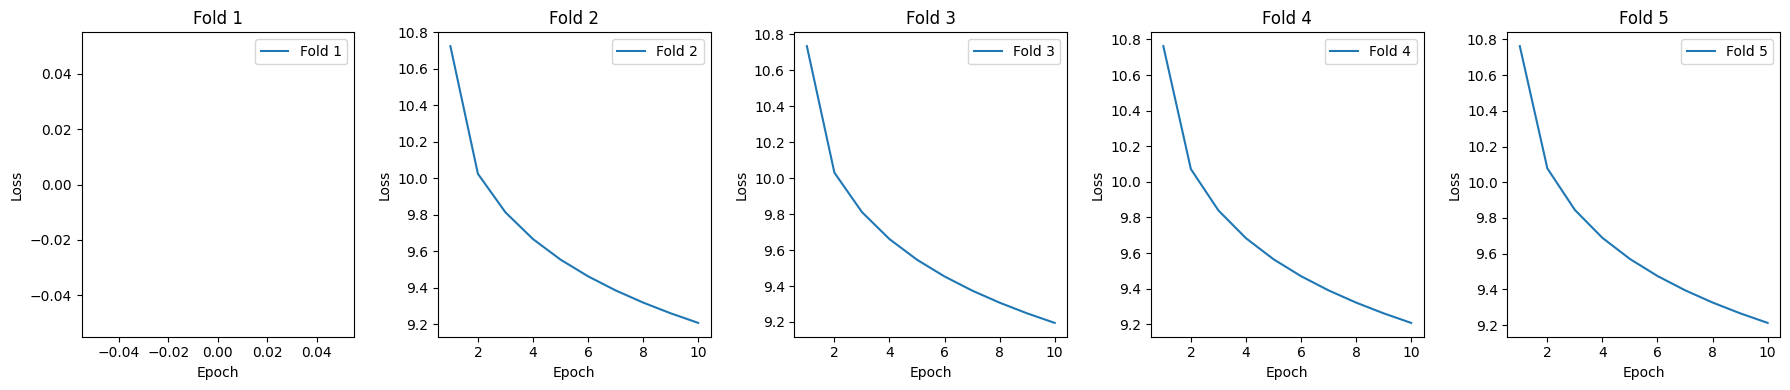

In [55]:
fig, axes = plt.subplots(1, 5, figsize=(18, 4))

for i, ax in enumerate(axes.flat):
    ax.plot(range(1, len(Loss[i]) + 1), Loss[i], label=f"Fold {i+1}")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.set_title(f"Fold {i+1}")
    ax.legend()

plt.tight_layout()
plt.show()

In [ ]:
train_loader = DataLoader(data, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(data, batch_size=batch_size, shuffle=False)

In [61]:
epochs = 10
Loss = []
model = LinearRegression()
optimizer = torch.optim.SGD(model.parameters(), lr=0.1)

for epoch in range(epochs):
    epoch_loss = 0
    for i, (features, labels) in enumerate(train_loader):
        optimizer.zero_grad()
        outputs = model(features).view(-1)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    Loss.append(epoch_loss / len(train_loader))
    print(f'Epoch: {epoch+1}/{epochs}. Train loss: {Loss[-1]:.4f}.')

TypeError: 'tuple' object cannot be interpreted as an integer

In [ ]:
def predict(model, test_loader):
    model.eval()
    predictions = []
    with torch.no_grad():
        for features, _ in test_loader:
            outputs = model(features)
            predictions.extend(outputs.numpy().flatten())
    return predictions

In [ ]:
preds = predict(model, test_loader)

In [ ]:
result = pd.DataFrame(preds, columns=['SalePrice'])